# Choosing `q`

`q` is the number of latent GPs and must be less than or equal to the number of outputs `p`. It acts as a rank:
the shared latent basis is taken from the top-`q` principal directions of `Y`, so
the singular-value spectrum of `Y` is a direct guide to a good `q`. `q` can be explicitly specified by choosing one of two ways upon intializing a MOOGP instance:

1. `q = 5`: Five latent components will be used. q must be less than or equal to the output dimension p
2. `var_threshold = 0.99`: Include q latent components such that 99% of the output variance are explained, using a singular value decomposition

> Recommendation: Start with a smaller value for `q` and increase if more performance is need.


In [9]:
# !pip install moogp
# !pip install matplotlib

import numpy as np
import matplotlib.pyplot as plt

from moogp.model import MOOGP
from moogp import evaluation

## 1. A dataset with known rank

We build `p = 12` outputs as linear mixtures of `r_true = 3` smooth latent
functions (drawn from a GP prior),
plus a little observation noise. By construction the response lives in a
3-dimensional subspace, so `q = 3` should suffice.

In [11]:
def se_kernel(x, lengthscale):
    """Squared-exponential covariance matrix for 1D inputs x."""
    sq_dist = (x[:, None] - x[None, :]) ** 2
    return np.exp(-0.5 * sq_dist / lengthscale ** 2)


def make_lowrank(n_points, p, r_true, lengthscale=0.2, noise_std=0.05, seed=7):
    """Simulate p outputs as noisy linear mixtures of r_true latent GPs."""
    rng = np.random.default_rng(seed)
    x = np.linspace(0, 1, n_points)

    # Draw r_true independent smooth functions from the same GP prior.
    cov = se_kernel(x, lengthscale) + 1e-8 * np.eye(n_points)
    chol = np.linalg.cholesky(cov)
    # prior sample f ~ N(0, cov)
    latent_fns = chol @ rng.standard_normal((n_points, r_true))  # shape: (n_points, r_true)

    # Linearly mix the latents into p outputs, then put each output on a
    # comparable scale (unit std) before adding observation noise.
    mixing_matrix = rng.standard_normal((p, r_true))  # (p, r_true)
    F = latent_fns @ mixing_matrix.T                  # (n_points, p)
    F = F / F.std(axis=0, keepdims=True)

    Y = F + rng.normal(0, noise_std, size=F.shape)
    return x.reshape(-1, 1), Y, F


p, r_true = 12, 3
X_all, Y_all, F_all = make_lowrank(n_points=150, p=p, r_true=r_true)

# Hold out half the points as a test set for the RMSE checks below.
n_train = 60
split_rng = np.random.default_rng(0)
shuffled_idx = split_rng.permutation(X_all.shape[0])
train_idx, test_idx = np.sort(shuffled_idx[:n_train]), np.sort(shuffled_idx[n_train:])

X, Y, F = X_all[train_idx], Y_all[train_idx], F_all[train_idx]
X_te, F_te = X_all[test_idx], F_all[test_idx]

print("X:", X.shape, " Y:", Y.shape, "  true latent rank:", r_true)

X: (60, 1)  Y: (60, 12)   true latent rank: 3


## 2. Inspect the singular-value spectrum of `Y`

The first thing to do before fitting is to look at the singular values of the
(centered) output matrix. A sharp drop after the `r`-th value signals that the
data is effectively rank-`r`.

singular values: [21.75 12.95  7.61  0.48  0.45  0.42  0.4   0.37]


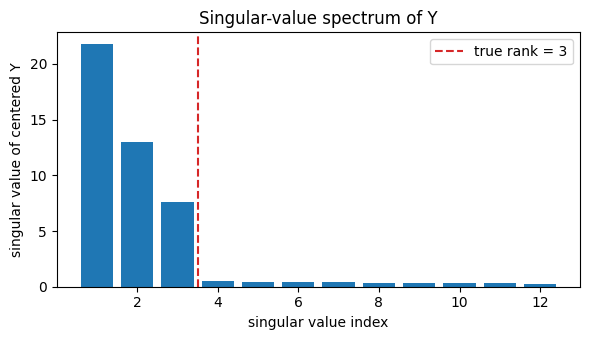

In [12]:
sv = np.linalg.svd(Y - Y.mean(0), compute_uv=False)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(np.arange(1, len(sv) + 1), sv, color="tab:blue")
ax.axvline(r_true + 0.5, color="tab:red", ls="--", label=f"true rank = {r_true}")
ax.set_xlabel("singular value index")
ax.set_ylabel("singular value of centered Y")
ax.set_title("Singular-value spectrum of Y")
ax.legend()
fig.tight_layout()

print("singular values:", np.round(sv[:8], 2))

Three singular values dominate and the rest collapse to near zero, which makes sense as we generated the data with three latent functions. Now confirm that predictive performance follows the same story.

In [13]:
qs = list(range(1, 8))
rmse_by_q = []
for q in qs:
    m = MOOGP(terms=[None, 1], q=q, orthogonal=True, learn_sigma_eps=True)
    m.fit({"X": X, "Y": Y}, optimizer_opts={"maxiter": 300})
    rmse_by_q.append(evaluation.rmse(F_te, m.predict(X_te)))
    print(f"q={q}: held-out RMSE (vs true f) = {rmse_by_q[-1]:.4f}")

q=1: held-out RMSE (vs true f) = 0.4431
q=2: held-out RMSE (vs true f) = 0.3861
q=3: held-out RMSE (vs true f) = 0.0156
q=4: held-out RMSE (vs true f) = 0.0156
q=5: held-out RMSE (vs true f) = 0.0160
q=6: held-out RMSE (vs true f) = 0.0156
q=7: held-out RMSE (vs true f) = 0.0156


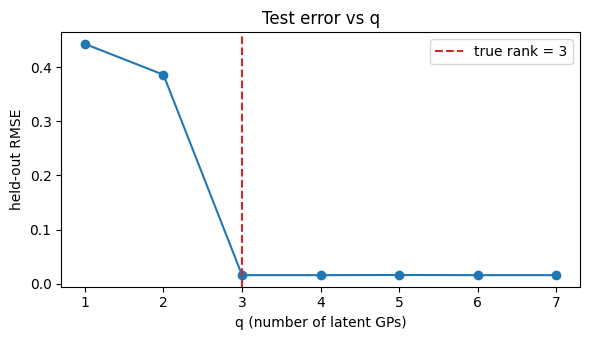

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(qs, rmse_by_q, "o-")
ax.axvline(r_true, color="tab:red", ls="--", label=f"true rank = {r_true}")
ax.set_xlabel("q (number of latent GPs)")
ax.set_ylabel("held-out RMSE")
ax.set_title("Test error vs q")
ax.legend()
fig.tight_layout()

The error drops sharply up to `q = 3` and then flattens: adding latent GPs beyond
the true rank neither helps nor hurts much, but costs compute. The
singular-value elbow and the RMSE elbow agree — both point to `q = 3`.

## 3. Letting MOOGP pick `q` with `var_threshold`

The two elbows above both came from the same place: the cumulative energy of the
singular values. Rather than reading that off a plot and hard-coding `q`, you can
hand the rule to MOOGP directly with `var_threshold`. It selects the smallest `q`
whose top singular directions capture at least that fraction of the output
variance — exactly the cumulative-energy curve we just looked at.

`q` and `var_threshold` are mutually exclusive: pass one or the other.

In [15]:
# Cumulative variance captured by the top-q directions of (standardized) Y.
Ystd = (Y - Y.mean(0)) / Y.std(0, ddof=1)
sv_q = np.linalg.svd(Ystd, compute_uv=False)
cumvar = np.cumsum(sv_q ** 2) / np.sum(sv_q ** 2)
print("cumulative variance:", np.round(cumvar[:6], 4))

# Fit once per threshold and report the q MOOGP selected on its own.
for thr in (0.90, 0.99, 0.999):
    m = MOOGP(terms=[None, 1], var_threshold=thr, orthogonal=True)
    m.fit({"X": X, "Y": Y}, optimizer_opts={"maxiter": 300})
    rmse = evaluation.rmse(F_te, m.predict(X_te))
    print(f"var_threshold={thr:<6} -> q={m.q}  held-out RMSE={rmse:.4f}")

cumulative variance: [0.6829 0.9171 0.9981 0.9985 0.9987 0.999 ]
var_threshold=0.9    -> q=2  held-out RMSE=0.3861
var_threshold=0.99   -> q=3  held-out RMSE=0.0156
var_threshold=0.999  -> q=6  held-out RMSE=0.0156


## 4. Example with Real Data

Many real multi-output datasets have a steep singular-value spectrum too. For example, data from computer simulations of heavy-ion collisions is included in `examples/nuclear_data` (see [here](https://arxiv.org/abs/2311.03306) for more info). The bundled nuclear-physics dataset has `p = 98` outputs but ~95% of its variance in the first singular direction, so a small `q` goes a long way. This is exactly the case where `var_threshold` is useful: a single threshold like `0.99` adapts the rank to the data without you ever counting singular values by hand.


p = 98 outputs; top-3 directions capture 99.0% of the variance


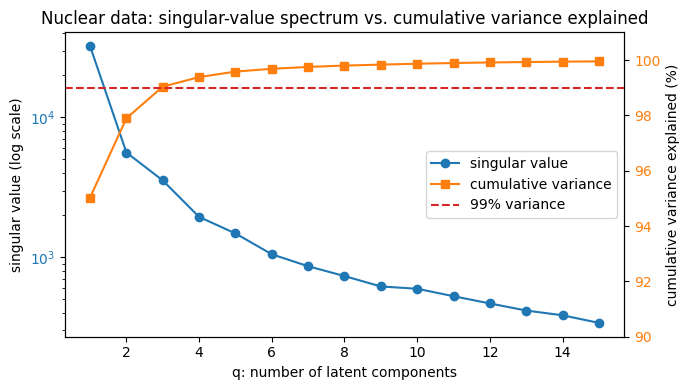

In [29]:
from pathlib import Path

def find_nuclear_dir():
    for base in (Path.cwd(), *Path.cwd().parents):
        for cand in (base / "examples" / "nuclear_data", base / "nuclear_data"):
            if (cand / "all_f.csv").exists():
                return cand
    raise FileNotFoundError("Could not locate examples/nuclear_data.")

Y_nuc = np.loadtxt(find_nuclear_dir() / "all_f.csv", delimiter=",")
sv_nuc = np.linalg.svd(Y_nuc - Y_nuc.mean(0), compute_uv=False)
energy = np.cumsum(sv_nuc ** 2) / np.sum(sv_nuc ** 2)

n_show = 15
idx = np.arange(1, n_show + 1)

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.semilogy(idx, sv_nuc[:n_show], "o-", color="tab:blue", label="singular value")
ax1.set_xlabel("q: number of latent components")
ax1.set_ylabel("singular value (log scale)")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_title("Nuclear data: singular-value spectrum vs. cumulative variance explained")

ax2 = ax1.twinx()
ax2.plot(idx, energy[:n_show] * 100, "s-", color="tab:orange", label="cumulative variance")
ax2.axhline(99, color="tab:red", ls="--", label="99% variance")
ax2.set_ylabel("cumulative variance explained (%)")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(90, 101)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

fig.tight_layout()
print(f"p = {Y_nuc.shape[1]} outputs; top-3 directions capture "
      f"{energy[2]:.1%} of the variance")

### Takeaways

  * `q` is a rank: `q <= p`, and `q = p` is full rank.
  * Inspect the singular-value spectrum of (centered) `Y` first — a sharp elbow
    suggests the rank.
  * Confirm with a held-out sweep: increase `q` until predictive performance
    plateaus.
  * To skip the manual search, pass `var_threshold` (e.g. `0.99`) and let MOOGP
    pick the smallest `q` that captures that fraction of the output variance.
    Use either `q` or `var_threshold`, not both.